In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report

In [25]:
df = pd.read_csv('spam.csv', encoding = 'latin-1')

In [26]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [27]:
df_nueva_data = df[['v1', 'v2']]
df_nueva_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [28]:
df_nueva_data = df_nueva_data.rename(
    columns = {
        'v1': 'categoria',
        'v2': 'descripcion'
    }
)

In [29]:
df_nueva_data.head(5)

,categoria,descripcion
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [30]:
X = df_nueva_data['descripcion']
y = df_nueva_data['categoria']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 19)

In [32]:
vectorizador = CountVectorizer()
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)

In [33]:
gaussian = GaussianNB()
gaussian.fit(X_train_vec.toarray(), y_train)

GaussianNB()

In [34]:
y_pred = gaussian.predict(X_test_vec.toarray())
print(y_pred)

['ham' 'spam' 'spam' ... 'spam' 'spam' 'ham']


In [35]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9061004784688995


In [36]:
f1 = f1_score(y_test, y_pred, pos_label = 'spam')
print(f1)

0.740495867768595


In [37]:
report = classification_report(y_test, y_pred, target_names=['spam', 'ham'])
print(report)

              precision    recall  f1-score   support

        spam       0.98      0.91      0.94      1425
         ham       0.63      0.91      0.74       247

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.93      0.91      0.91      1672



Implementar MultinomialNB, interpretación de métricas, gráficas de evaluación de modelo contrastando sus resultados.

In [38]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [39]:
multinomial = MultinomialNB()
multinomial.fit(X_train_vec, y_train)

MultinomialNB()

In [40]:
y_pred_multi = multinomial.predict(X_test_vec)
print(y_pred_multi)

['ham' 'spam' 'ham' ... 'spam' 'spam' 'ham']


In [41]:
accuracy_multi = accuracy_score(y_test, y_pred_multi)
f1_multi = f1_score(y_test, y_pred_multi, pos_label = 'spam')
recall_multi = recall_score(y_test, y_pred_multi, pos_label = 'spam')
precision_multi = precision_score(y_test, y_pred_multi, pos_label = 'spam')

print('Accuracy :', accuracy_multi)
print('Precision:', precision_multi)
print('Recall   :', recall_multi)
print('F1-score :', f1_multi)

Accuracy : 0.9856459330143541
Precision: 0.9704641350210971
Recall   : 0.9311740890688259
F1-score : 0.9504132231404959


In [42]:
report_multi = classification_report(y_test, y_pred_multi, target_names=['ham', 'spam'])
print(report_multi)

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1425
        spam       0.97      0.93      0.95       247

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



In [43]:
precision_gauss = precision_score(y_test, y_pred, pos_label = 'spam')
recall_gauss = recall_score(y_test, y_pred, pos_label = 'spam')
f1_gauss = f1_score(y_test, y_pred, pos_label = 'spam')
accuracy_gauss = accuracy_score(y_test, y_pred)

print('GaussianNB  -> Accuracy: {:.4f} | Precision: {:.4f} | Recall: {:.4f} | F1: {:.4f}'.format(
    accuracy_gauss, precision_gauss, recall_gauss, f1_gauss))
print('MultinomialNB -> Accuracy: {:.4f} | Precision: {:.4f} | Recall: {:.4f} | F1: {:.4f}'.format(
    accuracy_multi, precision_multi, recall_multi, f1_multi))

GaussianNB  -> Accuracy: 0.9061 | Precision: 0.6257 | Recall: 0.9069 | F1: 0.7405
MultinomialNB -> Accuracy: 0.9856 | Precision: 0.9705 | Recall: 0.9312 | F1: 0.9504


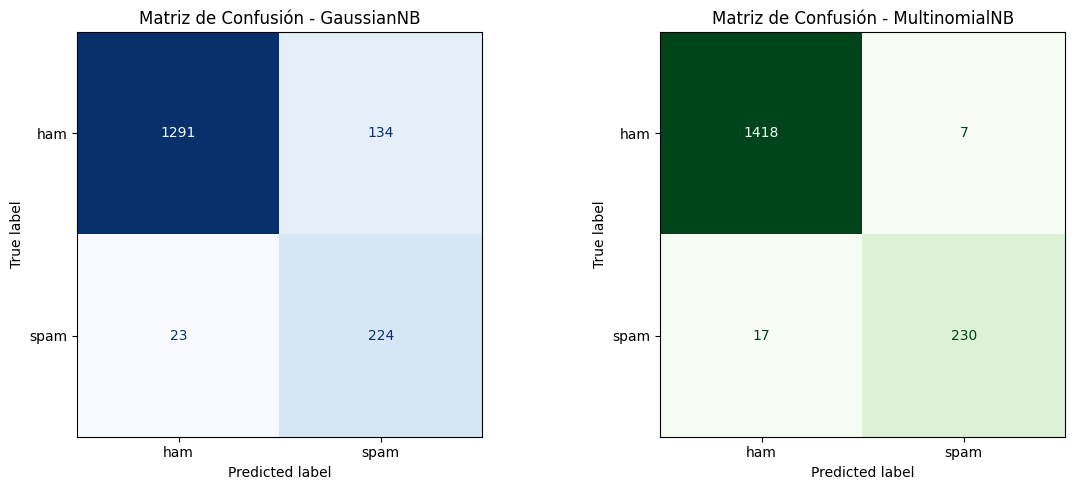

In [44]:
cm_gauss = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])
cm_multi = confusion_matrix(y_test, y_pred_multi, labels=['ham', 'spam'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = ConfusionMatrixDisplay(cm_gauss, display_labels=['ham', 'spam'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión - GaussianNB')

disp2 = ConfusionMatrixDisplay(cm_multi, display_labels=['ham', 'spam'])
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusión - MultinomialNB')

plt.tight_layout()
plt.show()

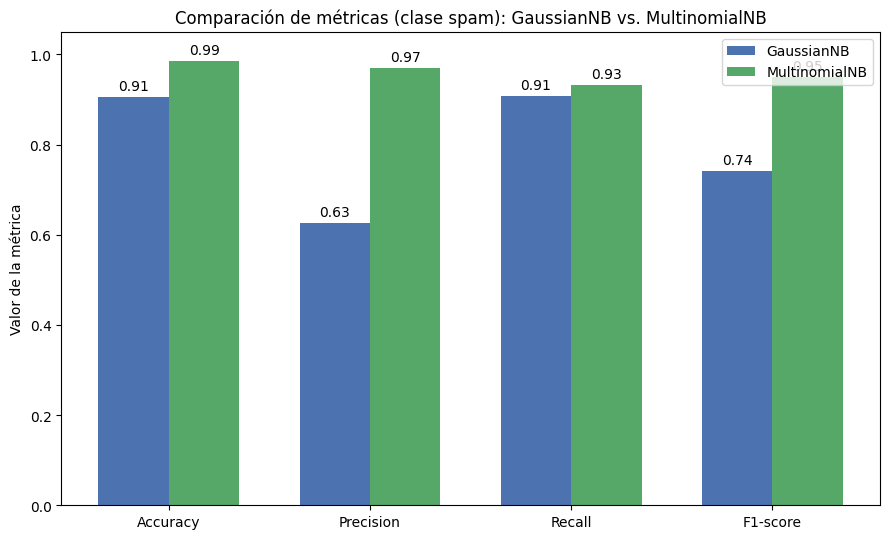

In [45]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-score']
valores_gauss = [accuracy_gauss, precision_gauss, recall_gauss, f1_gauss]
valores_multi = [accuracy_multi, precision_multi, recall_multi, f1_multi]

x = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
barras1 = ax.bar(x - ancho/2, valores_gauss, ancho, label='GaussianNB', color='#4C72B0')
barras2 = ax.bar(x + ancho/2, valores_multi, ancho, label='MultinomialNB', color='#55A868')

ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de métricas (clase spam): GaussianNB vs. MultinomialNB')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(barras1, fmt='%.2f', padding=3)
ax.bar_label(barras2, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

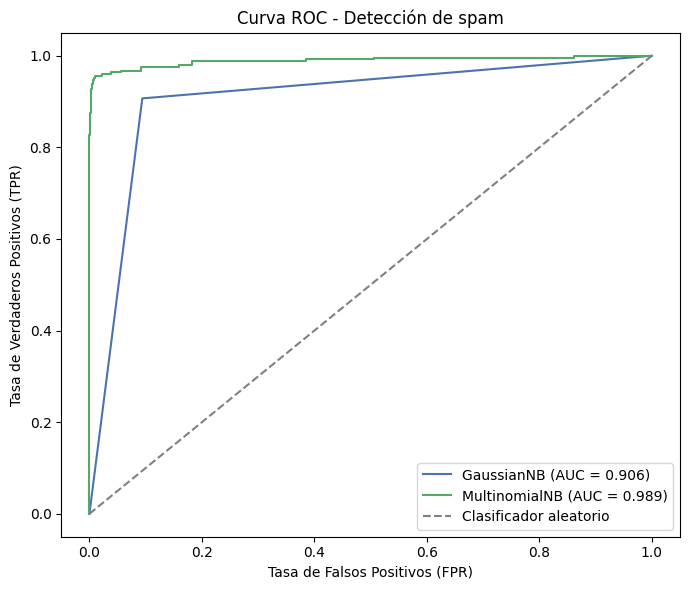

In [46]:
y_test_bin = (y_test == 'spam').astype(int)

idx_gauss = list(gaussian.classes_).index('spam')
idx_multi = list(multinomial.classes_).index('spam')

proba_gauss = gaussian.predict_proba(X_test_vec.toarray())[:, idx_gauss]
proba_multi = multinomial.predict_proba(X_test_vec)[:, idx_multi]

fpr_g, tpr_g, _ = roc_curve(y_test_bin, proba_gauss)
fpr_m, tpr_m, _ = roc_curve(y_test_bin, proba_multi)

auc_g = auc(fpr_g, tpr_g)
auc_m = auc(fpr_m, tpr_m)

plt.figure(figsize=(7, 6))
plt.plot(fpr_g, tpr_g, label='GaussianNB (AUC = {:.3f})'.format(auc_g), color='#4C72B0')
plt.plot(fpr_m, tpr_m, label='MultinomialNB (AUC = {:.3f})'.format(auc_m), color='#55A868')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Detección de spam')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()